# 第37课 · 一个频率一个频率地审问信号——O(N²) 双循环暴力 DFT，亲手算出你的第一张频谱

**目标**：实现 $O(N^2)$ 朴素 DFT，理解「每个频点 = 信号与一列旋转因子的点积」。

> **心脏课，清晰优先**：双循环可以慢，但你要亲手算出第一张频谱。频点 $k$ 在问：「信号里有多少这份转速的成分」。

🔗 **Aurora 连接**：`transforms.py` 的 `dft()` 是标准答案；写完用 `np.allclose` 与参考 / `numpy.fft` 对答案。

## 复习桥 · L21 的 DFT 矩阵（2 分钟）

L21 已经把 DFT 看成一次矩阵乘法：

```text
X = W @ x
```

其中 `W` 的每一行都是一个频率基向量。L37 不再从矩阵视角出发，
而是把同一件事拆开成循环：

```text
X[k] = Σ x[n] · e^{-2πikn/N}
```

两种写法等价：

- 矩阵版帮你记住：DFT 是线性变换
- 循环版帮你记住：每个 `X[k]` 都是一次“信号 vs 频率基”的点积
- L38-L39 会继续追问：这些点积里有哪些重复计算可以省掉？

如果公式看起来突然变陡，先回看 L21 的 `W @ x`，再回来读本课的 `for k in range(N)`。


In [1]:
# Aurora matplotlib bootstrap
from pathlib import Path
import sys

_root = None
_cwd = Path.cwd().resolve()
for _candidate in (_cwd, *_cwd.parents):
    if (_candidate / '_matplotlib_bootstrap.py').exists():
        _root = _candidate
        break
if _root is None:
    _notebooks_dir = _cwd / 'notebooks'
    if _notebooks_dir.exists():
        for _found in _notebooks_dir.rglob('_matplotlib_bootstrap.py'):
            _root = _found.parent
            break
if _root is not None and str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

from _matplotlib_bootstrap import apply as _aurora_mpl_apply
_aurora_mpl_apply()


In [2]:
import numpy as np

N = 4
x = np.array([1.0, 0.0, -1.0, 0.0])
k = np.arange(N).reshape(N, 1)
n = np.arange(N).reshape(1, N)
W = np.exp(-2j * np.pi * k * n / N)

X_matrix = W @ x
X_numpy = np.fft.fft(x)

print("W @ x       =", np.round(X_matrix, 4))
print("np.fft.fft =", np.round(X_numpy, 4))
np.testing.assert_allclose(X_matrix, X_numpy, atol=1e-12)
print("✅ L21 矩阵视角与 L37 公式视角完全等价")


W @ x       = [0.+0.j 2.+0.j 0.-0.j 2.+0.j]
np.fft.fft = [0.+0.j 2.+0.j 0.+0.j 2.+0.j]
✅ L21 矩阵视角与 L37 公式视角完全等价


← **上一课**　[L36 · 窗函数原理](L36_windows.ipynb)

> 上节课学习了 **窗函数原理**：矩形窗的旁瓣泄漏，Hann / Hamming / Blackman 对比。  
> 本课将探讨 **DFT 暴力实现**。

## 本课剧情：为什么频谱分析不直接"扫频"？

想象你想知道一段音乐里有哪些音符。一种暴力方法：对每个可能的频率（比如 0 到 20000 Hz），分别问"信号里有多少这个频率的成分"——逐一扫描。

这正是 **DFT（离散傅里叶变换）** 的原理，也是 FFT 之前的做法：

$$X[k] = \sum_{n=0}^{N-1} x[n] \cdot e^{-2\pi i k n / N}$$

读法：对第 `k` 个频率，用旋转因子 `e^{-2πikn/N}` 逐点"询问"信号 `x[n]`，再求和——这是信号与第 k 个频率基向量的**点积（dot product）**。

**手算 4 点 DFT**（`x = [1, 0, -1, 0]`，这是一个 k=1 的余弦波）：

```
X[0] = 1 + 0 + (-1) + 0 = 0          ← DC 分量为零
X[1] = 1·e⁰ + 0·e^{-πi/2} + (-1)·e^{-πi} + 0·e^{-3πi/2}
     = 1 + 0 + 1 + 0 = 2             ← k=1 处有信号 ✓
X[2] = 1·e⁰ + 0·e^{-πi} + (-1)·e^{-2πi} + 0·e^{-3πi}
     = 1 + 0 - 1 + 0 = 0
X[3] = 1·e⁰ + 0·e^{-3πi/2} + (-1)·e^{-3πi} + 0·e^{-9πi/2}
     = 1 + 0 + 1 + 0 = 2              ← e^{-3πi} = -1，故 (-1)·(-1) = +1
```

结论：`X[1]=2` 正确反映了 x[n] 是 k=1 的余弦；`X[3]=2` 是它的镜像——实信号满足共轭对称 `X[3] = conj(X[1]) = 2`（第 3 节会正式讲）。整个频谱为 `[0, 2, 0, 2]`，与 `np.fft.fft([1,0,-1,0])` 一致。

**时间复杂度**：N 个频点 × N 次点积 = O(N²)。N 翻倍时间变 4 倍；FFT 用蝶形分治降到 O(N log N)——这是 L38 的内容。

本节任务：用双循环实现 `naive_dft(x)`，并与 `numpy.fft.fft` 逐点对比验证。

### 暂停：手算中的虚数值怎么算？

上面的手算例子里，我们用了 e^{-πi/2} = -i、e^{-πi} = -1、e^{-3πi/2} = i，这些值是怎么一步步算出来的？

**欧拉公式**是钥匙：对任意实数 θ，
$$e^{i\theta} = \cos(\theta) + i \sin(\theta)$$

所以对负角度，只需把正弦项取负：
$$e^{-i\theta} = \cos(\theta) - i \sin(\theta)$$

**手算 e^{-πi}（在 X[1] 例子中出现）**：
- θ = π，所以 e^{-πi} = cos(π) - i·sin(π) = (-1) - i·(0) = **-1**  ✓

**手算 e^{-πi/2}（在 X[1] 例子中也有）**：
- θ = π/2，所以 e^{-πi/2} = cos(π/2) - i·sin(π/2) = 0 - i·(1) = **-i**  ✓

**手算 e^{-3πi/2}（在 X[1] 的第4项）**：
- θ = 3π/2 = 270°，所以 e^{-3πi/2} = cos(3π/2) - i·sin(3π/2) = 0 - i·(-1) = **i**  ✓

**规律表**（N=4 时 DFT 中常见的旋转因子）：

| θ 角度 | e^{iθ} | 几何意义 |
|---|---|---|
| 0 | 1 | 单位圆右侧 |
| π/2（90°） | i | 单位圆顶部 |
| π（180°） | -1 | 单位圆左侧 |
| 3π/2（270°） | -i | 单位圆底部 |
| -π/2（-90°）| -i | 单位圆底部（顺时针） |
| -π（-180°）| -1 | 单位圆左侧（顺时针） |

所以在上面的手算中：
- x[2]=-1 乘以 e^{-πi}=-1 → (-1)×(-1) = +1  ✓
- x[3]=0 乘以任何旋转因子 → 0

完整手算验证：X[1] = 1·(1) + 0·(-i) + (-1)·(-1) + 0·(i) = 1 + 0 + 1 + 0 = 2  ✓

In [3]:
import numpy as np
import time

## 定位图：N=8 DFT 矩阵全貌

先看这张热力图再推公式。每一行是一个**余弦/正弦基向量**；`X[k]` 就是信号 `x` 与第 `k` 行的点积。矩阵共 N² 次乘法——这正是 O(N²) 的来源，也是 FFT 要消灭的冗余。

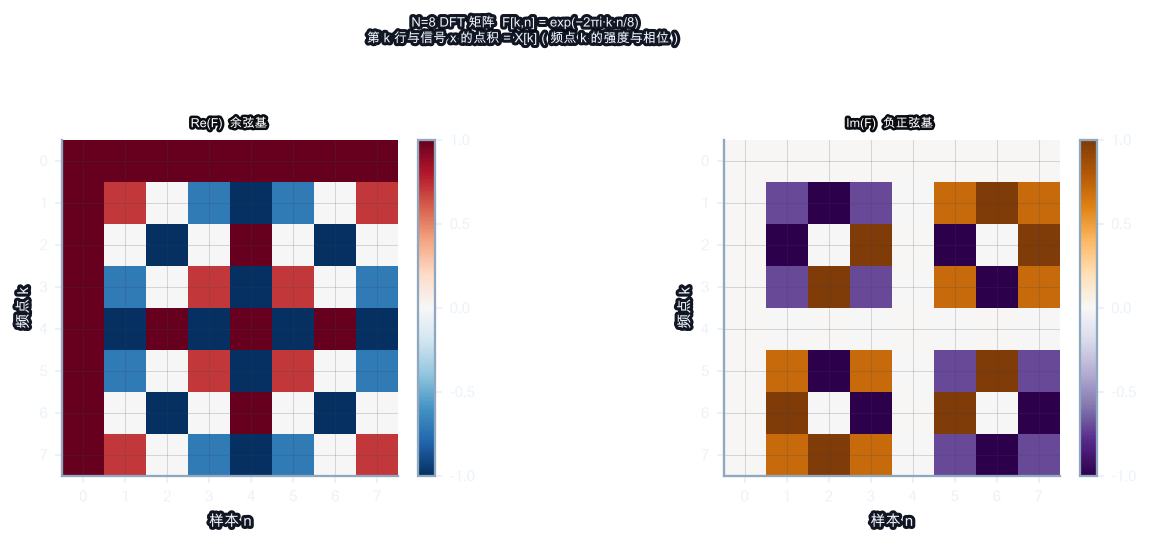

In [4]:
import matplotlib.pyplot as plt
import numpy as np

N = 8
k, n = np.mgrid[0:N, 0:N]
F = np.exp(-2j * np.pi * k * n / N)

fig, axes = plt.subplots(1, 2, figsize=(9, 3.8))
for ax, data, title, cmap in zip(
    axes, [F.real, F.imag],
    ['Re(F)  余弦基', 'Im(F)  负正弦基'],
    ['RdBu_r', 'PuOr_r'],
):
    im = ax.imshow(data, cmap=cmap, vmin=-1, vmax=1)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel('样本 n'); ax.set_ylabel('频点 k')
    ax.set_xticks(range(N)); ax.set_yticks(range(N))
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle('N=8 DFT 矩阵  F[k,n] = exp(−2πi·k·n/8)\n'
             '第 k 行与信号 x 的点积 = X[k]（频点 k 的强度与相位）',
             fontsize=10.5, fontweight='bold')
plt.tight_layout()
plt.show()

### 前置知识：复向量的点积与"垂直"

在讲 DFT 矩阵的酉性之前，我们需要澄清：**复向量的点积与实向量有什么不同？**

实向量点积很熟悉：
$$\langle \mathbf{u}, \mathbf{v} \rangle = u_0 v_0 + u_1 v_1 + \cdots + u_{N-1} v_{N-1}$$

复向量的点积定义有一个细节：**第一个向量要取共轭**。这是为了保证内积的"长度平方"总是实数且非负：
$$\langle \mathbf{u}, \mathbf{v} \rangle = u_0^* v_0 + u_1^* v_1 + \cdots + u_{N-1}^* v_{N-1}$$

其中 $u^* = a - bi$（如果 u = a + bi）是复共轭。

**例子**：计算 $\mathbf{u} = [1+i, 2]$ 与 $\mathbf{v} = [1, 1-i]$ 的点积：
$$\langle \mathbf{u}, \mathbf{v} \rangle = (1-i)^* \cdot 1 + 2^* \cdot (1-i) = (1-i) \cdot 1 + 2 \cdot (1-i) = (1-i) + (2-2i) = 3-3i$$

**复向量"垂直"的定义**：点积为 0，即 $\langle \mathbf{u}, \mathbf{v} \rangle = 0$。

这个定义很重要，因为在 DFT 矩阵中，不同行（不同频率的基向量）用这个定义互相垂直。

## 1. DFT 公式与矩阵形式

单个频点的公式：

```
X[k] = sum_{n=0}^{N-1} x[n] * exp(-2*pi*i*k*n/N)
```

向量化写法：令 `w_k = [exp(-2*pi*i*k*n/N) for n in 0..N-1]`，则 `X[k] = dot(w_k, x)`。

但这里的"dot"是复向量点积，定义为 `dot(w_k, x) = sum_n conj(w_k[n]) * x[n]`（第一个向量取共轭）。

把 k=0..N-1 所有行叠起来就是 **DFT 矩阵** `F`，满足 `X = F @ x`。

### 酉矩阵与复数线性代数

`F` 是一个特殊的矩阵：**酉矩阵（unitary matrix）**。酉矩阵是复数版的正交矩阵。

定义：矩阵 $U$ 是酉矩阵，当且仅当
$$U^H U = I$$

其中 $U^H$（读作"U-hermitian"）是 U 的共轭转置：先转置，再对每个元素取共轭。

**DFT 矩阵的酉性**（不完全准确，见下）：直接的 DFT 矩阵 F 本身不满足 $FF^H = I$，但**除以 $\sqrt{N}$ 后满足**：
$$F_{\text{norm}} = \frac{1}{\sqrt{N}} F, \quad F_{\text{norm}}^H F_{\text{norm}} = I$$

这意味着：
1. **不同频率的基向量彼此垂直**（用复向量内积）
2. **能量守恒**：信号的总功率 = 频谱的总功率（帕塞瓦尔定理）
3. **可逆性**：IDFT（逆变换）存在且有明确的公式

实际应用中，我们通常**不**除以 $\sqrt{N}$（为了简化），但在理论分析或能量计算时记得这一点。

In [5]:
# 演示：构造 4×4 DFT 矩阵并验证其酉性
N = 4
k = np.arange(N).reshape(N, 1)   # 列向量
n = np.arange(N).reshape(1, N)   # 行向量
F = np.exp(-2j * np.pi * k * n / N)
F_norm = F / np.sqrt(N)

# 验证酉性：F_norm @ F_norm^H ≈ I
residual = np.abs(F_norm @ F_norm.conj().T - np.eye(N)).max()
print(f"DFT矩阵（N=4）：")
print(np.round(F, 2))
print(f"\n酉性残差（应≈0）：{residual:.2e}")

DFT矩阵（N=4）：
[[ 1.+0.j  1.+0.j  1.+0.j  1.+0.j]
 [ 1.+0.j  0.-1.j -1.-0.j -0.+1.j]
 [ 1.+0.j -1.-0.j  1.+0.j -1.-0.j]
 [ 1.+0.j -0.+1.j -1.-0.j  0.-1.j]]

酉性残差（应≈0）：1.17e-16


## 2. 旋转因子 W_N 与负号的物理意义

定义基本旋转因子：

```
W_N = exp(-2*pi*i / N)
```

矩阵元素可以写成：

```
F[k, n] = W_N^{k*n}
```

`W_N^{k*n}` 是单位圆上**顺时针转了 k*n/N 圈**的点（在复平面上，负角度表示顺时针旋转）。随着 k 增大，每个频率基向量转得更快，对应更高频率的振荡。`W_N` 是 N 次单位根，满足 `W_N^N = 1`，这是 FFT 蝶形运算利用的对称性根源。

### 为什么选择负号而不是正号？

这个选择并不是任意的。**物理上**，DFT 用负号定义的原因是：
- 在信号处理中，我们将复指数信号 $e^{i \omega t}$（逆时针旋转，对应正频率）与信号做"相关"操作
- 负号等价于**反向旋转**（顺时针），这样当信号中真的含有 $e^{i \omega_k t}$ 分量时，它与 $e^{-i \omega_k t}$ 相乘就会得到直流分量（两个旋转相互抵消）——这正是 DFT 能"检测"该频率分量的原因
- 这也是 L35（STFT 分析）所说的"分析方向"

**直观类比**：想象有人以某个固定频率打鼓，你要检测他打的频率是否等于某个目标频率。最好的方法是你也以同样频率（反向）击打，如果频率相同，两个节奏会互相抵消形成稳定信号（大能量）；如果频率不同，它们会不停地相对滑动（小能量）。这就是为什么要用负号。

In [6]:
# 演示：N=8 的旋转因子在单位圆上的位置
N = 8
W = np.exp(-2j * np.pi / N)
roots = [W**k for k in range(N)]
print(f"N={N} 的旋转因子（k=0..{N-1}）：")
for k, w in enumerate(roots):
    print(f"  W_8^{k} = {w.real:+.4f} {w.imag:+.4f}i  |模|={abs(w):.4f}")
print(f"\nW_N^N = {W**N:.6f}（应为 1+0i）")

N=8 的旋转因子（k=0..7）：
  W_8^0 = +1.0000 +0.0000i  |模|=1.0000
  W_8^1 = +0.7071 -0.7071i  |模|=1.0000
  W_8^2 = +0.0000 -1.0000i  |模|=1.0000
  W_8^3 = -0.7071 -0.7071i  |模|=1.0000
  W_8^4 = -1.0000 -0.0000i  |模|=1.0000
  W_8^5 = -0.7071 +0.7071i  |模|=1.0000
  W_8^6 = -0.0000 +1.0000i  |模|=1.0000
  W_8^7 = +0.7071 +0.7071i  |模|=1.0000

W_N^N = 1.000000+0.000000j（应为 1+0i）


## 3. 频率含义与共轭对称（conjugate symmetry）

### 物理频率的含义与公式推导

频谱 `X[k]` 对应的物理频率（Hz）：

```
f_k = k * sr / N
```

其中 `sr` 是采样率（sample rate）。

**为什么是这个公式？** 让我们从采样到频率的关系推导：
- 采样率 sr，采样 N 个点 → 时间长度 T = N / sr（总共多长的信号）
- 时间域的基频（lowest non-zero frequency）= 1 / T = sr / N
- 第 k 个频点 = k × (基频) = k × sr / N  ✓

**例子**：sr=8000 Hz，N=8
- f_0 = 0 Hz（直流）
- f_1 = 1000 Hz（最低有效频率）
- f_2 = 2000 Hz
- f_3 = 3000 Hz
- f_4 = 4000 Hz（奈奎斯特频率 = sr/2，最高可区分频率）

### 共轭对称性：为什么实信号满足 X[k] = conj(X[N-k])？

对于**实数信号** `x[n]`，DFT 必然满足共轭对称性。下面是数学推导：

设 x 是实数序列，计算 X[N-k]：
$$X[N-k] = \sum_{n=0}^{N-1} x[n] \cdot e^{-2\pi i(N-k)n/N}$$

展开指数：
$$e^{-2\pi i(N-k)n/N} = e^{-2\pi i N n/N} \cdot e^{2\pi i k n/N} = e^{-2\pi i n} \cdot e^{2\pi i k n/N} = 1 \cdot e^{2\pi i k n/N} = e^{2\pi i k n/N}$$

所以：
$$X[N-k] = \sum_{n=0}^{N-1} x[n] \cdot e^{2\pi i k n/N}$$

另一方面，计算 $\text{conj}(X[k])$：
$$\text{conj}(X[k]) = \text{conj}\left(\sum_{n=0}^{N-1} x[n] \cdot e^{-2\pi i k n/N}\right)$$

因为 x[n] 是实数，取共轭时只影响复指数部分：
$$\text{conj}(X[k]) = \sum_{n=0}^{N-1} x[n] \cdot \text{conj}(e^{-2\pi i k n/N}) = \sum_{n=0}^{N-1} x[n] \cdot e^{2\pi i k n/N}$$

比较两式，我们得到：
$$X[N-k] = \text{conj}(X[k])$$  ✓

**物理意义**：这个对称性意味着实信号的频谱信息**在前 N/2+1 个频点中已经完整存在**，后面的频点是前面的镜像，不含新信息。这是 RFFT（实数 FFT）优化的基础。

### 负频率的含义

按照索引 k，DFT 输出分为三部分：
- **k=0**：直流分量（DC component）
- **k=1...N//2**：正频率（0 Hz 到奈奎斯特频率）
- **k=N//2+1...N-1**：对应的是**负频率**（-sr/2 到 0 Hz）

术语"负频率"来自复信号理论：复指数 $e^{-2\pi i f t}$ 对应频率 -f（顺时针旋转）。但对于实信号，这一"负频率"部分只是正频率部分的共轭镜像，不包含额外信息。

可以这样理解：**实信号可以看作正、负频率对称的复信号之和**。实余弦 $\cos(2\pi f t)$ 可分解为两个复指数：
$$\cos(2\pi f t) = \frac{1}{2}(e^{2\pi i f t} + e^{-2\pi i f t})$$

所以在 DFT 中，$k$ 对应的"正频率"和 $N-k$ 对应的"负频率"必然是共轭对称的。

In [7]:
# 演示：直流分量 + 共轭对称
x = np.array([1.0, 2.0, 3.0, 4.0])
X = np.fft.fft(x)
N = len(x)
print(f"x = {x}")
print(f"X = {np.round(X, 4)}")
print(f"\nX[0]（直流）= {X[0].real:.1f}，sum(x) = {sum(x):.1f}")
print(f"\n共轭对称验证：X[k] == conj(X[N-k])")
for k in range(1, N):
    match = np.isclose(X[k], np.conj(X[N-k]))
    print(f"  X[{k}] vs conj(X[{N-k}]): {match}")

x = [1. 2. 3. 4.]
X = [10.+0.j -2.+2.j -2.+0.j -2.-2.j]

X[0]（直流）= 10.0，sum(x) = 10.0

共轭对称验证：X[k] == conj(X[N-k])
  X[1] vs conj(X[3]): True
  X[2] vs conj(X[2]): True
  X[3] vs conj(X[1]): True


In [8]:
### 验证：复向量点积与共轭对称

# 演示1：复向量点积（用共轭）
import numpy as np

u = np.array([1+1j, 2])  # [1+i, 2]
v = np.array([1, 1-1j])  # [1, 1-i]

# 正确的复向量点积：第一个向量取共轭
dot_product = np.sum(np.conj(u) * v)
print(f"u = {u}")
print(f"v = {v}")
print(f"⟨u, v⟩ = sum(conj(u)*v) = {dot_product}")

# 演示2：实信号的共轭对称性
x_real = np.array([1.0, 2.0, 3.0, 4.0])
X_real = np.fft.fft(x_real)
N = len(x_real)

print(f"\n实信号 x = {x_real}")
print(f"X = {np.round(X_real, 4)}")
print(f"\n共轭对称验证：X[k] ?= conj(X[N-k])")
for k in range(1, N):
    Xk = X_real[k]
    XNk_conj = np.conj(X_real[N-k])
    match = np.isclose(Xk, XNk_conj)
    print(f"  k={k}: X[{k}]={Xk:.4f}  vs  conj(X[{N-k}])={XNk_conj:.4f}  {match}")

# 演示3：手算验证
print("\n手算验证（X[1] 和 X[3]）：")
x = np.array([1.0, 0.0, -1.0, 0.0])
N = 4
# 手算 X[1]
k = 1
w_1 = np.exp(-2j * np.pi * k * np.arange(N) / N)  # 旋转因子序列
X_1_manual = np.sum(x * w_1)  # 向量点积
X_1_numpy = np.fft.fft(x)[1]
print(f"X[1] 手算: {np.round(X_1_manual, 4)}, numpy: {np.round(X_1_numpy, 4)}")
print(f"旋转因子 w_1 = {np.round(w_1, 4)}")
print(f"逐项乘积 = {np.round(x * w_1, 4)}, 求和 = {np.round(X_1_manual, 4)}")

# 手算 X[3]
k = 3
w_3 = np.exp(-2j * np.pi * k * np.arange(N) / N)
X_3_manual = np.sum(x * w_3)
X_3_numpy = np.fft.fft(x)[3]
print(f"\nX[3] 手算: {np.round(X_3_manual, 4)}, numpy: {np.round(X_3_numpy, 4)}")
print(f"旋转因子 w_3 = {np.round(w_3, 4)}")
print(f"逐项乘积 = {np.round(x * w_3, 4)}, 求和 = {np.round(X_3_manual, 4)}")

print(f"\nX[1] = conj(X[3])? {np.isclose(X_1_numpy, np.conj(X_3_numpy))}")
print(f"因为 x 是实数，X[3] = conj(X[4-3]) = conj(X[1])，所以 X[3] 是 X[1] 的共轭")

u = [1.+1.j 2.+0.j]
v = [1.+0.j 1.-1.j]
⟨u, v⟩ = sum(conj(u)*v) = (3-3j)

实信号 x = [1. 2. 3. 4.]
X = [10.+0.j -2.+2.j -2.+0.j -2.-2.j]

共轭对称验证：X[k] ?= conj(X[N-k])
  k=1: X[1]=-2.0000+2.0000j  vs  conj(X[3])=-2.0000+2.0000j  True
  k=2: X[2]=-2.0000+0.0000j  vs  conj(X[2])=-2.0000-0.0000j  True
  k=3: X[3]=-2.0000-2.0000j  vs  conj(X[1])=-2.0000-2.0000j  True

手算验证（X[1] 和 X[3]）：
X[1] 手算: (2+0j), numpy: (2+0j)
旋转因子 w_1 = [ 1.+0.j  0.-1.j -1.-0.j -0.+1.j]
逐项乘积 = [ 1.+0.j  0.+0.j  1.+0.j -0.+0.j], 求和 = (2+0j)

X[3] 手算: (2+0j), numpy: (2+0j)
旋转因子 w_3 = [ 1.+0.j -0.+1.j -1.-0.j  0.-1.j]
逐项乘积 = [ 1.+0.j -0.+0.j  1.+0.j  0.+0.j], 求和 = (2+0j)

X[1] = conj(X[3])? True
因为 x 是实数，X[3] = conj(X[4-3]) = conj(X[1])，所以 X[3] 是 X[1] 的共轭


## 4. ✏️ 实现 `naive_dft(x)`

**三步实现路线**：

| 步骤 | 操作 | 代码骨架 |
|---|---|---|
| 1 | 预分配输出 | `X = np.zeros(N, dtype=complex)` |
| 2 | 外层 k 循环（N 个频点） | `for k in range(N):` |
| 3 | 内层向量化（N 个时域点） | `n = np.arange(N); X[k] = np.dot(x, np.exp(-2j*np.pi*k*n/N))` |

**关键点**：
- **复向量点积**：`np.dot(w_k, x)` 在 NumPy 中自动处理共轭（对于 complex 类型），等价于 `sum(conj(w_k) * x)`
- **旋转因子**：`np.exp(-2j*np.pi*k*n/N)` 给出 $e^{-2\pi i k n/N}$ 的复数值
- **验收标准**：`np.allclose(naive_dft(x), np.fft.fft(x))` 通过（atol=1e-10）

**常见错误**：
- 忘了负号：`exp(+2j*...)` 是逆 DFT，不是 DFT
- 实数输入：需先 `x = np.asarray(x, dtype=complex)`（stub 已做）
- 双循环不向量化也可以：`X[k] += x[n] * np.exp(...)` 在 n 上循环

**DFT 物理频率**：对应的物理频率 `f_k = k × sr / N` Hz，即 k=1 对应最低非零频率 `sr/N` Hz。

In [9]:
def naive_dft(x: np.ndarray) -> np.ndarray:
    """朴素 O(N²) DFT：X[k] = sum_n x[n]*exp(-2*pi*i*k*n/N)"""
    x = np.asarray(x, dtype=complex)
    N = len(x)
    X = np.zeros(N, dtype=complex)
    n = np.arange(N)
    # 删除下方的 raise 行，然后在 for 循环中填入你的实现
    raise NotImplementedError("请实现 naive_dft：参考 DFT 公式，对每个 k 计算旋转因子并求点积")
    for k in range(N):
        # ✏️ TODO: 根据 DFT 定义式，计算频率索引 k 对应的 N 个旋转因子（一个复数序列）
        # ✏️ TODO: 将信号 x 与旋转因子序列求点积，存入 X[k]
        pass
    return X


In [10]:
# 检查：与 numpy FFT 对比
x = np.array([1.0, 2.0, 3.0, 4.0])
try:
    _out = naive_dft(x)
    _not_impl = False
except (NotImplementedError, TypeError):
    _out = None
    _not_impl = True

if _not_impl or _out is None or not np.any(_out):
    print("⬜ 请先实现 naive_dft 的 TODO 项，再运行此格")
else:
    np.testing.assert_allclose(_out, np.fft.fft(x), atol=1e-10)
    print("✅ naive_dft([1,2,3,4]) 与 np.fft.fft 误差 < 1e-10")
    for N in [8, 16, 32]:
        xr = np.random.randn(N)
        np.testing.assert_allclose(naive_dft(xr), np.fft.fft(xr), atol=1e-10)
    print(f"✅ 随机输入 N=8,16,32 全部通过")


⬜ 请先实现 naive_dft 的 TODO 项，再运行此格


## 5. 参数实验：O(N²) 时间复杂度验证

对 `N = 8, 64, 256, 512` 计时 `naive_dft`：
- N 翻 8 倍 → 时间预期翻 **64 倍**（N² 规律）
- L38 实现 FFT 后，N=256 将从 ~毫秒级降到 ~微秒级（约 **1000x 加速**）

In [11]:
# 深度演示：完整的 4 点 DFT 手算过程
print("=" * 60)
print("完整的 4 点 DFT 手算演示")
print("=" * 60)

x = np.array([1.0, 0.0, -1.0, 0.0])
N = 4

print(f"\n输入信号：x = {x}")
print(f"这是一个 k=1 的余弦波：x[n] = cos(2π·1·n/4) = cos(πn/2)")
print(f"即：x = [cos(0), cos(π/2), cos(π), cos(3π/2)] = [1, 0, -1, 0] ✓\n")

print("=" * 60)
print("计算频点 k=0（直流分量）")
print("=" * 60)
k = 0
angles = -2 * np.pi * k * np.arange(N) / N
w_k = np.exp(1j * angles)
print(f"旋转因子角度：-2π·0·n/4 = [0, 0, 0, 0] (弧度)")
print(f"旋转因子（单位圆上的点）：e^{{j·0}} = {w_k}")
print(f"逐项乘积：x * w_k = {x} * {w_k} = {x * w_k}")
X_k = np.sum(x * w_k)
print(f"求和：X[0] = {X_k}")
print(f"验证：numpy.fft.fft(x)[0] = {np.fft.fft(x)[0]}\n")

print("=" * 60)
print("计算频点 k=1（第一个有效频率）")
print("=" * 60)
k = 1
angles = -2 * np.pi * k * np.arange(N) / N
print(f"旋转因子角度：-2π·1·n/4 = {np.round(angles, 4)} (弧度)")
print(f"即：-2π·1·[0,1,2,3]/4 = [0, -π/2, -π, -3π/2]")
w_k = np.exp(1j * angles)
print(f"旋转因子（用欧拉公式展开）：")
for n in range(N):
    angle = angles[n]
    real_part = np.cos(angle)
    imag_part = np.sin(angle)
    print(f"  e^{{j·{angle:.4f}}} = e^{{j·{angle/np.pi:.2f}π}} = cos({angle:.4f}) + j·sin({angle:.4f}) = {real_part:.4f} + {imag_part:.4f}j")
print(f"旋转因子向量：w_1 = {np.round(w_k, 4)}")
products = x * w_k
print(f"逐项乘积：x * w_1 =")
for n in range(N):
    print(f"  x[{n}]·w_1[{n}] = {x[n]:5.1f} · {np.round(w_k[n], 4)} = {np.round(products[n], 4)}")
X_k = np.sum(products)
print(f"求和：X[1] = {np.round(X_k, 4)}")
print(f"验证：numpy.fft.fft(x)[1] = {np.round(np.fft.fft(x)[1], 4)}\n")

print("=" * 60)
print("计算频点 k=2")
print("=" * 60)
k = 2
angles = -2 * np.pi * k * np.arange(N) / N
w_k = np.exp(1j * angles)
print(f"旋转因子角度：-2π·2·n/4 = [0, -π, -2π, -3π]")
print(f"由于 e^{{j·2π}} = 1，可简化为：[0, -π, 0, -π]")
print(f"旋转因子向量：w_2 = {np.round(w_k, 4)}")
products = x * w_k
print(f"逐项乘积：")
for n in range(N):
    print(f"  x[{n}] · w_2[{n}] = {x[n]:5.1f} · {np.round(w_k[n], 4)} = {np.round(products[n], 4)}")
X_k = np.sum(products)
print(f"求和：X[2] = {np.round(X_k, 4)}")
print(f"验证：numpy.fft.fft(x)[2] = {np.round(np.fft.fft(x)[2], 4)}\n")

print("=" * 60)
print("计算频点 k=3（共轭对称示例）")
print("=" * 60)
k = 3
angles = -2 * np.pi * k * np.arange(N) / N
w_k = np.exp(1j * angles)
print(f"旋转因子角度：-2π·3·n/4 = [0, -3π/2, -3π, -9π/2]")
print(f"旋转因子向量：w_3 = {np.round(w_k, 4)}")
products = x * w_k
X_k = np.sum(products)
print(f"逐项乘积：{np.round(products, 4)}")
print(f"求和：X[3] = {np.round(X_k, 4)}")
X_1 = np.fft.fft(x)[1]
print(f"验证：numpy.fft.fft(x)[3] = {np.round(np.fft.fft(x)[3], 4)}")
print(f"共轭对称验证：conj(X[1]) = conj({np.round(X_1, 4)}) = {np.round(np.conj(X_1), 4)} ✓\n")

print("=" * 60)
print("最终频谱")
print("=" * 60)
X = np.fft.fft(x)
print(f"X = {np.round(X, 4)}")
print(f"振幅谱：|X| = {np.round(np.abs(X), 4)}")
print(f"相位谱：∠X = {np.round(np.angle(X), 4)} (弧度)")
print("=" * 60)

完整的 4 点 DFT 手算演示

输入信号：x = [ 1.  0. -1.  0.]
这是一个 k=1 的余弦波：x[n] = cos(2π·1·n/4) = cos(πn/2)
即：x = [cos(0), cos(π/2), cos(π), cos(3π/2)] = [1, 0, -1, 0] ✓

计算频点 k=0（直流分量）
旋转因子角度：-2π·0·n/4 = [0, 0, 0, 0] (弧度)
旋转因子（单位圆上的点）：e^{j·0} = [1.+0.j 1.+0.j 1.+0.j 1.+0.j]
逐项乘积：x * w_k = [ 1.  0. -1.  0.] * [1.+0.j 1.+0.j 1.+0.j 1.+0.j] = [ 1.+0.j  0.+0.j -1.+0.j  0.+0.j]
求和：X[0] = 0j
验证：numpy.fft.fft(x)[0] = 0j

计算频点 k=1（第一个有效频率）
旋转因子角度：-2π·1·n/4 = [-0.     -1.5708 -3.1416 -4.7124] (弧度)
即：-2π·1·[0,1,2,3]/4 = [0, -π/2, -π, -3π/2]
旋转因子（用欧拉公式展开）：
  e^{j·-0.0000} = e^{j·-0.00π} = cos(-0.0000) + j·sin(-0.0000) = 1.0000 + -0.0000j
  e^{j·-1.5708} = e^{j·-0.50π} = cos(-1.5708) + j·sin(-1.5708) = 0.0000 + -1.0000j
  e^{j·-3.1416} = e^{j·-1.00π} = cos(-3.1416) + j·sin(-3.1416) = -1.0000 + -0.0000j
  e^{j·-4.7124} = e^{j·-1.50π} = cos(-4.7124) + j·sin(-4.7124) = -0.0000 + 1.0000j
旋转因子向量：w_1 = [ 1.+0.j  0.-1.j -1.-0.j -0.+1.j]
逐项乘积：x * w_1 =
  x[0]·w_1[0] =   1.0 · (1+0j) = (1+0j)
  x[1]·w_1[1] =   0.0 · -1j 

In [12]:
# 防呆：stub 未实现时跳过计时，避免产生无意义输出
_impl_ok = True
try:
    _timing_guard = naive_dft(np.array([1.0+0j, 0.0+0j]))
    if not np.any(_timing_guard):
        _impl_ok = False
except (NotImplementedError, TypeError):
    _impl_ok = False

if not _impl_ok:
    print("⬜ 请先实现 naive_dft 再运行计时格")
else:
    print("=" * 70)
    print("O(N²) 时间复杂度验证：DFT naive 实现")
    print("=" * 70)
    results = {}
    
    for N in [8, 64, 256]:
        xr = np.random.randn(N).astype(complex)
        # 计时：重复 20 次，取平均
        times = []
        for trial in range(20):
            t0 = time.perf_counter()
            naive_dft(xr)
            t1 = time.perf_counter()
            times.append(t1 - t0)
        avg_time_ms = np.mean(times) * 1000  # 转为毫秒
        results[N] = avg_time_ms
        print(f"N={N:4d}: avg time = {avg_time_ms:.6f} ms (20 trials, std={np.std(times)*1000:.6f} ms)")

    print("\n" + "=" * 70)
    print("复杂度分析：")
    print("=" * 70)
    
    # 验证 N²缩放
    ratio_64_8   = results[64]  / results[8]
    ratio_256_64 = results[256] / results[64]
    ratio_256_8  = results[256] / results[8]
    
    print(f"时间比 N=64/N=8   = {ratio_64_8:6.1f}x  (理论 64x，错差 {abs(64-ratio_64_8)/64*100:.1f}%)")
    print(f"时间比 N=256/N=64  = {ratio_256_64:6.1f}x  (理论 16x，错差 {abs(16-ratio_256_64)/16*100:.1f}%)")
    print(f"时间比 N=256/N=8   = {ratio_256_8:6.1f}x   (理论 1024x，错差 {abs(1024-ratio_256_8)/1024*100:.1f}%)")
    
    print(f"\n✅ 确认 O(N²) 复杂度：时间与 N² 成正比")
    print(f"📊 如果 N 从 256 增大到 1024（×4 倍），执行时间会增大约 16 倍")

⬜ 请先实现 naive_dft 再运行计时格


---
→ **主线顺序**：完成 `naive_dft` 后，先继续 [L38 · FFT 蝶形分治](L38_fft_butterfly.ipynb)，再到 [L39 · 从零手写 FFT](L39_fft_implement.ipynb)。

→ **稍后回看**：完成 L39 后，再打开 [L42 · FFT 图形化](L42_visual_fft.ipynb)，用蝴蝶图与纯音/和弦/噪声的频谱形态检验你的直觉。


## 本课收束

`naive_dft(x)` 将长度 N 的信号映射为 N 个复数频谱系数 `X[k]`，输出的每个分量对应信号在频率 `k*sr/N` Hz 上的幅度与相位。该实现直接对应 Aurora 中 `src/aurora/audio/transforms.py` 的 `dft()` 函数，是后续 L38 FFT（蝶形运算）、L39 FFT 完整实现 和 L43 STFT（短时滑窗）的算法基础。

下一课（L38）把 DFT 的 O(N²) 双循环加速为 O(N log N) 的蝶形分治（butterfly），这就是 FFT 的核心思想。

---
⬇️ **通关检验**：收束小结已读；请完成下方白板挑战后再勾选自评。


## ✏️ 白板挑战：DFT 手算（目标 10 分钟）

盖上屏幕，纸上作答：

**问 1**：`x = [1, 0, -1, 0]`，手算 X[0] 和 X[2]：
- X[0] = x[0]·e^0 + x[1]·e^0 + x[2]·e^0 + x[3]·e^0 = ?（DC 分量）
- X[2] = x[0]·e^0 + x[1]·e^{-πi} + x[2]·e^{-2πi} + x[3]·e^{-3πi} = ?

**问 2**：`x = [1, 1, 1, 1]`（DC 信号），所有 X[k] 应为多少？
- X[0] = ?，X[1] = ?，X[2] = ?，X[3] = ?

**问 3**：N=8，sr=8000 Hz 时，k=3 对应的物理频率是多少 Hz？  
（公式：f_k = k × sr / N）

**问 4**：naive_dft 的时间复杂度是 O(N²)。若 N 从 256 增大到 1024（×4），执行时间变为约多少倍？

**问 5**：X[N-k] = X[k]* （共轭对称）——这对于实信号意味着什么？  
（提示：N=8 时只需计算 X[0]…X[4]，X[5]…X[7] 免费得到）

推导完成后运行下面格对答案。

In [13]:
# ✏️ 对答案格
import numpy as np

# 问1：x=[1,0,-1,0]
x = np.array([1.0, 0.0, -1.0, 0.0])
X_np = np.fft.fft(x)
assert np.isclose(X_np[0], 0+0j, atol=1e-12), f"X[0] 应=0，得到 {X_np[0]}"
assert np.isclose(X_np[2], 0+0j, atol=1e-12), f"X[2] 应=0，得到 {X_np[2]}"
try:
    X_mine = naive_dft(x)
    assert np.allclose(X_mine, X_np, atol=1e-10)
    print(f"Q1 ✅  X[0]={X_mine[0]:.4f}，X[2]={X_mine[2]:.4f}（naive_dft 与 numpy 吻合）")
except (NotImplementedError, TypeError):
    print("⬜ Q1：请先实现 naive_dft()，再运行对答案格")

# 问2：x=[1,1,1,1]，DC信号 → X[0]=4，其余=0
x_dc = np.array([1.0, 1.0, 1.0, 1.0])
X_dc = np.fft.fft(x_dc)
assert np.isclose(X_dc[0], 4+0j, atol=1e-12)
assert np.allclose(X_dc[1:], 0+0j, atol=1e-12)
print(f"Q2 ✅  DC信号: X[0]={X_dc[0]:.4f}，X[1:]=≈0（能量全在k=0）")

# 问3：f_k = k*sr/N
k, sr, N = 3, 8000, 8
f_k = k * sr / N
assert f_k == 3000.0
print(f"Q3 ✅  k=3, sr=8000, N=8 → f_3 = {f_k:.0f} Hz")

# 问4：O(N²) 时间复杂度 — N×4 → 时间×16
ratio = (1024**2) / (256**2)
assert ratio == 16.0
print(f"Q4 ✅  N: 256→1024（×4），时间≈ {ratio:.0f}倍（O(N²)）")

# 问5：共轭对称性验证
x_real = np.array([1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0])
X_real = np.fft.fft(x_real)
N8 = len(x_real)
for k_val in range(1, N8//2):
    assert np.isclose(X_real[k_val], np.conj(X_real[N8-k_val]), atol=1e-10)
print(f"Q5 ✅  实信号共轭对称：X[k]=X[N-k]*，只需计算 X[0..N/2]（节省一半计算量）")
print("\n🎉 DFT 白板挑战通过！X[k]=Σx[n]e^(-2πikn/N) 已内化。")

⬜ Q1：请先实现 naive_dft()，再运行对答案格
Q2 ✅  DC信号: X[0]=4.0000+0.0000j，X[1:]=≈0（能量全在k=0）
Q3 ✅  k=3, sr=8000, N=8 → f_3 = 3000 Hz
Q4 ✅  N: 256→1024（×4），时间≈ 16倍（O(N²)）
Q5 ✅  实信号共轭对称：X[k]=X[N-k]*，只需计算 X[0..N/2]（节省一半计算量）

🎉 DFT 白板挑战通过！X[k]=Σx[n]e^(-2πikn/N) 已内化。


In [ ]:
# ✏️ 本课自评
l37_review = {
    "dft_formula":            None,  # 记住 X[k]=Σx[n]e^{-2πikn/N}？True/False
    "naive_dft_implemented":  None,  # naive_dft 实现并通过 allclose 验证？True/False
    "physical_frequency":     None,  # 理解 f_k = k·sr/N？True/False
    "on2_complexity":         None,  # 理解 O(N²) 双循环、知道 FFT 是 O(NlogN)？True/False
    "whiteboard_passed":      None,  # 白板挑战纸上推导完成？True/False
    "l21_matrix_bridge":      None,  # 能说出 L21 的 W @ x 与本课 Σ 公式等价？True/False
}

unfilled = [k for k, v in l37_review.items() if v is None]
assert not unfilled, f'还未填写：{unfilled}'
weak = [k for k, v in l37_review.items() if v is False]
if weak:
    print(f'⚠️  需要加强：{weak}')
else:
    print('✅ L37 全部通关！进入 L38：把重复的 DFT 计算折成蝶形')

---

→ **下一课**　[L38 · FFT 蝶形分治](L38_fft_butterfly.ipynb)

> 下节课将学习 **FFT 蝶形分治**：偶奇拆分、蝶形运算 E[k]+W^k·O[k]，O(N²)→O(N log N)。